In [1]:
## be/analysis/utils/jc1_be_loop.py
# -*- coding: utf-8 -*-
"""
Created on Wed Jun 29 11:13:22 2016

@author: Rama K. Vasudevan, Stephen Jesse, Suhas Somnath, Chris R. Smith

Various helper functions for aiding loop fitting and projection
"""

from __future__ import division, print_function, absolute_import, unicode_literals

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import least_squares
from scipy.optimize import leastsq
from scipy.spatial import ConvexHull
from scipy.special import erf, erfinv
import warnings
from scipy.optimize import curve_fit

# switching32 = np.dtype([('V+', np.float32),
#                         ('V-', np.float32),
#                         ('Imprint', np.float32),
#                         ('R+', np.float32),
#                         ('R-', np.float32),
#                         ('Switchable Polarization', np.float32),
#                         ('Work of Switching', np.float32),
#                         ('Nucleation Bias 1', np.float32),
#                         ('Nucleation Bias 2', np.float32)])
field_names = ['V+', 'V-', 'Imprint', 'R+', 'R-', 'Switchable Polarization',
               'Work of Switching', 'Nucleation Bias 1', 'Nucleation Bias 2']
switching32 = np.dtype({'names': field_names,
                        'formats': [float for name in field_names]})


###############################################################################


def calculate_loop_centroid(vdc, loop_vals):
    """
    Calculates the centroid of a single given loop. Uses polyogonal centroid, 
    see wiki article for details.
    
    Parameters
    -----------
    vdc : 1D list or numpy array
        DC voltage steps
    loop_vals : 1D list or numpy array
        unfolded loop
    
    Returns
    -----------
    cent : tuple
        (x,y) coordinates of the centroid
    area : float
        geometric area
    """

    vdc = np.squeeze(np.array(vdc))
    num_steps = vdc.size

    x_vals = np.zeros(num_steps - 1)
    y_vals = np.zeros(num_steps - 1)
    area_vals = np.zeros(num_steps - 1)

    for index in range(num_steps - 1):
        x_i = vdc[index]
        x_i1 = vdc[index + 1]
        y_i = loop_vals[index]
        y_i1 = loop_vals[index + 1]

        x_vals[index] = (x_i + x_i1) * (x_i * y_i1 - x_i1 * y_i)
        y_vals[index] = (y_i + y_i1) * (x_i * y_i1 - x_i1 * y_i)
        area_vals[index] = (x_i * y_i1 - x_i1 * y_i)

    area = 0.50 * np.sum(area_vals)
    cent_x = (1.0 / (6.0 * area)) * np.sum(x_vals)
    cent_y = (1.0 / (6.0 * area)) * np.sum(y_vals)

    return (cent_x, cent_y), area


###############################################################################

def get_rotation_matrix(theta):
    """
    Returns the rotation matrix in 2D, given the angle theta

    Parameters
    ----------
    theta : float
        Angle in radians

    Returns
    ---------
    mat : 2D numpy array
        rotation matrix
    """
    return np.array([[np.cos(theta), -1 * np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])


###############################################################################

def projectLoop(vdc, amp_vec, phase_vec):
    """
    This function projects a single loop cycle using the amplitude and phase vectors

    Parameters
    ------------
    vdc : 1D list or numpy array
        DC voltages. vector of length N
    amp_vec : 1D numpy array
        amplitude of response
    phase_vec : 1D numpy array
        phase of response

    Returns
    ----------
    results : dictionary
        Results from projecting the provided vectors with following components

        'Projected Loop' : 1D numpy array
            projected loop matrix
        'Rotation Matrix' : tuple
            rotation angle [rad] for the projecting, as well as the offset value
        'Centroid' : M-length list of tuples
            (x,y) positions of centroids for each projected loop
        'Geometric Area' : M element long numpy array
            geometric area of the loop
    """

    def f_min(x_mat, p):
        plane_xyz = p[0:3]
        distance = (plane_xyz * x_mat.T).sum(axis=1) + p[3]
        return distance / np.linalg.norm(plane_xyz)

    def residuals(params, signal, X):
        return f_min(X, params)

    a_cos_phi = amp_vec * np.cos(phase_vec)
    a_sin_phi = amp_vec * np.sin(phase_vec)

    # Fit to a plane
    # Plane equation Ax + By + Cz = D
    XYZ = np.vstack((vdc, a_cos_phi, a_sin_phi))  # Data points in 3D

    # Initial guess of the plane
    p0 = [1, .5, -1, .5]

    # do the fitting
    sol = leastsq(residuals, p0, args=(None, XYZ))[0]
    A = sol[0]
    B = sol[1]
    C = sol[2]
    D = sol[3]

    # Choose a voltage range and y range and plot the plane with these values.i.e.,
    # plot z = (D-Ax-By)/C
    x = np.linspace(np.min(vdc), np.max(vdc), 200)
    y = np.linspace(np.min(a_cos_phi), np.max(a_cos_phi), 200)

    xx, yy = np.meshgrid(x, y)  # x and y limits
    zz = (-D - A * xx - B * yy) / C

    '''Number of points in the linear fit.
    This will make the offset more accurate, but 100 is reasonable.'''
    num_pt_fit = 100

    '''Plot the a_cos_phi/a_sin_phi part of the plane as well.
    This is the projection onto the y-z plane.
    Given the equation Ax + By + Cz =D, and given x is the voltage,
    we want only the By and Cz = D part.
    so, yproj = D-Cz/B and and zproj = D-By/C'''

    # Now we need to calculate the perpendicular distance to the origin
    y_proj = (-D - C * zz[:, 0]) / B
    z_proj = (-D - B * yy[:, 0]) / C

    # Only print the first warning
    with warnings.catch_warnings():
        warnings.simplefilter("once")
        p = np.polyfit(y_proj, z_proj, 1)  # Fit a straight line
    xdat_fit = np.linspace(y_proj.min(), y_proj.max(), num_pt_fit)
    ydat_fit = np.polyval(p, xdat_fit)

    # Find the point on the line closest to the origin

    pdist_vals = np.zeros(shape=len(xdat_fit))
    for point in range(len(xdat_fit)):
        pdist_vals[point] = np.linalg.norm(np.array([0, 0]) -
                                           np.array([xdat_fit[point], ydat_fit[point]]))

    min_point_ind = np.where(pdist_vals == pdist_vals.min())[0][0]
    min_point = np.array([xdat_fit[min_point_ind], ydat_fit[min_point_ind]])
    offset_dist = np.linalg.norm(np.array([0, 0]) - min_point)
    rot_angle = np.tan(p[0])

    # Now adjust the loop by first subtracting offset
    xdata_minus_off = a_cos_phi - xdat_fit[min_point_ind]
    ydata_minus_off = a_sin_phi - ydat_fit[min_point_ind]

    # Do the rotation
    R = get_rotation_matrix(rot_angle)
    R_orth = get_rotation_matrix(np.pi + rot_angle)

    ydat_new = np.dot(R, [xdata_minus_off, ydata_minus_off])  # This has the rotated components
    ydat_new_orth = np.dot(R_orth, [xdata_minus_off,
                                    ydata_minus_off])  # This has rotated components, but using the other angle.

    # taking only the first index, since this is all that was being used.
    ydat_new = ydat_new[0, :]
    ydat_new_orth = ydat_new_orth[0, :]

    """
    Now determine whether the correct one is clockwise or counter clockwise
    The data that we need is ydat_new and ydat_new_orth
    We are going to calculate the center of mass of the rotated loop
    Using definition of centroid of a polygon (see wikipedia https://en.wikipedia.org/wiki/Centroid#Centroid_of_polygon)
    """

    # Centroid calculation also gives geometric area. If the area is positive then the loop rotates the correct way.
    # If the area is negative it rotates the 'wrong' way.

    # print ydat_new.shape, ydat_new_orth.shape
    c_point, geo_area_loop = calculate_loop_centroid(vdc, ydat_new)
    c_point_orth, geo_area_loop_orth = calculate_loop_centroid(vdc, ydat_new_orth)

    # Based on the above we can see that the blue curve gives the correct rotation angle.
    if geo_area_loop > 0:
        pr_vec = ydat_new  # [0,:]
        centroid = c_point
        geo_area = geo_area_loop
        rot_angle = rot_angle
    else:
        pr_vec = ydat_new_orth  # [0,:]
        centroid = c_point_orth
        geo_area = geo_area_loop_orth
        rot_angle = rot_angle + np.pi

    results = {'Projected Loop': pr_vec.ravel(), 'Rotation Matrix': (rot_angle, offset_dist),
               'Centroid': centroid, 'Geometric Area': geo_area}  # Dictionary of Results from projecting

    return results


###############################################################################


def loop_fit_function(vdc, *coef_vec):
    """
    9 parameter fit function
    
    Parameters
    -----------
    vdc : 1D numpy array or list
        DC voltages
    coef_vec : 1D numpy array or list
        9 parameter coefficient vector
        
    Returns
    ---------
    loop_eval : 1D numpy array
        Loop values
    """

    a = coef_vec[:5]
    b = coef_vec[5:]
    d = 1000

    v1 = np.asarray(vdc[:int(len(vdc) / 2)])
    v2 = np.asarray(vdc[int(len(vdc) / 2):])

    g1 = (b[1] - b[0]) / 2 * (erf((v1 - a[2]) * d) + 1) + b[0]
    g2 = (b[3] - b[2]) / 2 * (erf((v2 - a[3]) * d) + 1) + b[2]

    y1 = (g1 * erf((v1 - a[2]) / g1) + b[0]) / (b[0] + b[1])
    y2 = (g2 * erf((v2 - a[3]) / g2) + b[2]) / (b[2] + b[3])

    f1 = a[0] + a[1] * y1 + a[4] * v1
    f2 = a[0] + a[1] * y2 + a[4] * v2

    loop_eval = np.hstack((f1, f2))
    return loop_eval


def loop_fit_jacobian(vdc, coef_vec):
    # TODO: Jacobian function gives different results from the analytic Jacobian
    """
    Jacobian of 9 parameter fit function

    Parameters
    -----------
    vdc : 1D numpy array or list
        DC voltages
    coef_vec : 1D numpy array or list
        9 parameter coefficient vector

    Returns
    ---------
    F : 2D numpy array
        function values
    """

    a = coef_vec[:5]
    b = coef_vec[5:]
    d = 1000

    vdc = np.squeeze(np.array(vdc))
    num_steps = vdc.size

    J = np.zeros([num_steps, 9], dtype=float)

    V1 = vdc[:int(num_steps / 2)]
    V2 = vdc[int(num_steps / 2):]

    g1 = (b[1] - b[0]) / 2 * (erf((V1 - a[2]) * d) + 1) + b[0]
    g2 = (b[3] - b[2]) / 2 * (erf((V2 - a[3]) * d) + 1) + b[2]

    # Some useful fractions
    oosqpi = 1.0 / np.sqrt(np.pi)
    oob01 = 1.0 / (b[0] + b[1])
    oob23 = 1.0 / (b[2] + b[3])

    # Derivatives of g1 and g2
    dg1a2 = -(b[1] - b[0]) / oosqpi * d * np.exp(-(V1 - a[2]) ** 2)
    dg2a3 = -(b[3] - b[2]) / oosqpi * d * np.exp(-(V2 - a[3]) ** 2)
    dg1b0 = -0.5 * (erf(V1 - a[2]) * d + 1)
    dg1b1 = -dg1b0
    dg2b2 = -0.5 * (erf(V2 - a[3]) * d + 1)
    dg2b3 = -dg2b2

    Y1 = oob01 * (g1 * erf((V1 - a[2]) / g1) + b[0])
    Y2 = oob23 * (g2 * erf((V2 - a[3]) / g2) + b[2])

    # Derivatives of Y1 and Y2
    dY1g1 = oob01 * (erf((V1 - a[2]) / g1) - 2 * oosqpi * np.exp(-(V1 - a[2]) ** 2 / g1 ** 2))
    dY2g2 = oob23 * (erf((V2 - a[4]) / g2) - 2 * oosqpi * np.exp(-(V2 - a[4]) ** 2 / g2 ** 2))

    dY1a2 = -2 * oosqpi * oob01 * np.exp(-(V1 - a[2]) ** 2 / g1 ** 2)

    dY2a3 = -2 * oosqpi * oob01 * np.exp(-(V2 - a[3]) ** 2 / g2 ** 2)

    dY1b0 = oob01 * (1 - Y1)
    dY1b1 = -oob01 * Y1

    dY2b2 = oob23 * (1 - Y2)
    dY2b3 = -oob23 * Y2

    '''
    Jacobian terms
    '''
    zeroV = np.zeros_like(V1)
    # Derivative with respect to a[0] is always 1
    J[:, 0] = 1

    # Derivative with respect to a[1] is different for F1 and F2
    J[:, 1] = np.hstack((Y1, Y2))

    # Derivative with respect to a[2] is zero for F2, but not F1
    J21 = a[1] * (dY1g1 * dg1a2 + dY1a2)
    J22 = zeroV
    J[:, 2] = np.hstack((J21, J22))

    # Derivative with respect to a[3] is zero for F1, but not F2
    J31 = zeroV
    J32 = a[1] * (dY2g2 * dg2a3 + dY2a3)
    J[:, 3] = np.hstack((J31, J32))

    # Derivative with respect to a[4] is vdc
    J[:, 4] = vdc

    # Derivative with respect to b[0] is zero for F2, but not F1
    J51 = a[1] * (dY1g1 * dg1b0 + dY1b0)
    J52 = zeroV
    J[:, 5] = np.hstack((J51, J52))

    # Derivative with respect to b[1] is zero for F2, but not F1
    J61 = a[1] * (dY1g1 * dg1b1 + dY1b1)
    J62 = zeroV
    J[:, 6] = np.hstack((J61, J62))

    # Derivative with respect to b[2] is zero for F1, but not F2
    J71 = zeroV
    J72 = a[1] * (dY2g2 * dg2b2 + dY2b2)
    J[:, 7] = np.hstack((J71, J72))

    # Derivative with respect to b[3] is zero for F1, but not F2
    J81 = zeroV
    J82 = a[1] * (dY2g2 * dg2b3 + dY2b3)
    J[:, 8] = np.hstack((J81, J82))

    return J


###############################################################################


def get_switching_coefs(loop_centroid, loop_coef_vec):
    """
    Parameters
    -----------
    loop_centroid : tuple or 1D list or numpy array
        [x,y] position of loop centroid
    loop_coef_vec : 1D list or numpy array
        a 9 length vector of coefficients describing the loop via the 9 loop parmeter fit
    
    Returns
    --------
    switching_labels_dict : dictionary
        switching labels and values
    """
    # calculate nucleation bias
    anv = loop_coef_vec[0:5]
    bnv = loop_coef_vec[5:]
    nuc_threshold = .97

    lc_x = loop_centroid[0]

    # Upper Branch
    B = bnv[2]
    nuc_v01a = B * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / B) - abs(anv[2])

    B = bnv[3]
    nuc_v01b = B * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / B) - abs(anv[2])

    # Choose the voltage which is closer to the centroid x value.
    if abs(nuc_v01a - lc_x) <= abs(nuc_v01b - lc_x):
        nuc_1 = nuc_v01a
    else:
        nuc_1 = nuc_v01b

    if np.isinf(nuc_1):
        nuc_1 = 0

    # Lower Branch
    B = bnv[0]
    nuc_v02a = B * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / B) + abs(anv[3])

    B = bnv[1]
    nuc_v02b = B * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / B) + abs(anv[3])

    if abs(nuc_v02a - lc_x) <= abs(nuc_v02b - lc_x):
        nuc_2 = nuc_v02a
    else:
        nuc_2 = nuc_v02b

    if np.isinf(nuc_2):
        nuc_2 = 0

    # calculate switching parameters
    switching_coef_vec = np.zeros(shape=(9, 1))

    switching_coef_vec[0] = loop_coef_vec[2]
    switching_coef_vec[1] = loop_coef_vec[3]
    switching_coef_vec[2] = (loop_coef_vec[3] + loop_coef_vec[2]) / 2
    switching_coef_vec[3] = loop_coef_vec[0] + loop_coef_vec[1]
    switching_coef_vec[4] = loop_coef_vec[0]
    switching_coef_vec[5] = loop_coef_vec[1]
    switching_coef_vec[6] = abs((loop_coef_vec[2] - loop_coef_vec[3]) * abs(loop_coef_vec[1]))
    switching_coef_vec[7] = nuc_1
    switching_coef_vec[8] = nuc_2

    switching_labels_dict = {'V-': switching_coef_vec[0], 'V+': switching_coef_vec[1],
                             'Imprint': switching_coef_vec[2], 'R+': switching_coef_vec[3],
                             'R-': switching_coef_vec[4], 'Switchable Polarization': switching_coef_vec[5],
                             'Work of Switching': switching_coef_vec[6],
                             'Nucleation Bias 1': nuc_1, 'Nucleation Bias 2': nuc_2}

    return switching_labels_dict


##############################################################################


def calc_switching_coef_vec(loop_coef_vec, nuc_threshold=0.03):
    """
    Calculates the physical loop parameters from the array of loop parameters.

    Parameters
    ----------
    loop_coef_vec : numpy.ndarray
        Array of loop coeffiecients
    nuc_threshold : float
        Nucleation threshold

    Returns
    -------
    switching_coef_vec : numpy.ndarray
        Array of loop parameters
    """
    switching_coef_vec = np.zeros(shape=loop_coef_vec.shape[0], dtype=switching32)

    anv = loop_coef_vec[:, :5].T
    bnv = loop_coef_vec[:, 5:].T

    nuc_v01a = bnv[2] * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / bnv[2]) + anv[3]
    nuc_v01b = bnv[3] * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / bnv[3]) + anv[3]

    nuc_v01 = np.where(np.isfinite(nuc_v01a), nuc_v01a,
                       np.where(np.isfinite(nuc_v01b), nuc_v01b, -1E-10))

    nuc_v02a = bnv[0] * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / bnv[0]) + anv[2]
    nuc_v02b = bnv[1] * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / bnv[1]) + anv[2]

    nuc_v02 = np.where(np.isfinite(nuc_v02a), nuc_v02a,
                       np.where(np.isfinite(nuc_v02b), nuc_v02b, -1E-10))

    switching_coef_vec['V+'] = loop_coef_vec[:, 3]
    switching_coef_vec['V-'] = loop_coef_vec[:, 2]
    switching_coef_vec['Imprint'] = (loop_coef_vec[:, 2] + loop_coef_vec[:, 3]) / 2
    switching_coef_vec['R+'] = loop_coef_vec[:, 0] + loop_coef_vec[:, 1]
    switching_coef_vec['R-'] = loop_coef_vec[:, 0]
    switching_coef_vec['Switchable Polarization'] = loop_coef_vec[:, 1]
    switching_coef_vec['Work of Switching'] = np.abs(loop_coef_vec[:, 3] -
                                                     loop_coef_vec[:, 2]) * np.abs(loop_coef_vec[:, 1])

    switching_coef_vec['Nucleation Bias 1'] = nuc_v01
    switching_coef_vec['Nucleation Bias 2'] = nuc_v02

    return switching_coef_vec.reshape([-1, 1])


def generate_guess(vdc, pr_vec, show_plots=False):
    """
    Given a single unfolded loop and centroid return the intial guess for the fitting.
    We generate most of the guesses by looking at the loop centroid and looking
    at the nearest intersection points with the loop, which is a polygon.

    Parameters
    -----------
    vdc : 1D numpy array
        DC offsets
    pr_vec : 1D numpy array
        Piezoresponse or unfolded loop
    show_plots : Boolean (Optional. Default = False)
        Whether or not the plot the convex hull, centroid, intersection points

    Returns
    -----------------
    init_guess_coef_vec : 1D Numpy array
        Fit guess coefficient vector
    """

    points = np.transpose(np.array([np.squeeze(vdc), pr_vec]))  # [points,axis]

    geom_centroid, geom_area = calculate_loop_centroid(points[:, 0], points[:, 1])

    hull = ConvexHull(points)

    """
    Now we need to find the intersection points on the N,S,E,W
    the simplex of the complex hull is essentially a set of line equations.
    We need to find the two lines (top and bottom) or (left and right) that
    interect with the vertical / horizontal lines passing through the geometric centroid
    """

    def find_intersection(A, B, C, D):
        """
        Finds the coordinates where two line segments intersect

        Parameters
        ------------
        A, B, C, D : Tuple or 1D list or 1D numpy array
            (x,y) coordinates of the points that define the two line segments AB and CD

        Returns
        ----------
        obj : None or tuple
            None if not intersecting. (x,y) coordinates of intersection
        """

        def ccw(A, B, C):
            """Credit - StackOverflow"""
            return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])

        def line(p1, p2):
            """Credit - StackOverflow"""
            A = (p1[1] - p2[1])
            B = (p2[0] - p1[0])
            C = (p1[0] * p2[1] - p2[0] * p1[1])
            return A, B, -C

        def intersection(L1, L2):
            """
            Finds the intersection of two lines (NOT line segments).
            Credit - StackOverflow
            """
            D = L1[0] * L2[1] - L1[1] * L2[0]
            Dx = L1[2] * L2[1] - L1[1] * L2[2]
            Dy = L1[0] * L2[2] - L1[2] * L2[0]
            if D != 0:
                x = Dx / D
                y = Dy / D
                return x, y
            else:
                return None

        if ((ccw(A, C, D) is not ccw(B, C, D)) and (ccw(A, B, C) is not ccw(A, B, D))) is False:
            return None
        else:
            return intersection(line(A, B), line(C, D))

    # start and end coordinates of each line segment defining the convex hull
    outline_1 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    outline_2 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    for index, pair in enumerate(hull.simplices):
        outline_1[index, :] = points[pair[0]]
        outline_2[index, :] = points[pair[1]]

    """Find the coordinates of the points where the vertical line through the
    centroid intersects with the convex hull"""
    y_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [geom_centroid[0], hull.min_bound[1]],
                                 [geom_centroid[0], hull.max_bound[1]])
        if x_pt is not None:
            y_intersections.append(x_pt)

    '''
    Find the coordinates of the points where the horizontal line through the
    centroid intersects with the convex hull
    '''
    x_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [hull.min_bound[0], geom_centroid[1]],
                                 [hull.max_bound[0], geom_centroid[1]])
        if x_pt is not None:
            x_intersections.append(x_pt)

    '''
    Default values if not intersections can be found.
    '''
    if len(y_intersections) < 2:
        min_y_intercept = min(pr_vec)
        max_y_intercept = max(pr_vec)
    else:
        min_y_intercept = min(y_intersections[0][1], y_intersections[1][1])
        max_y_intercept = max(y_intersections[0][1], y_intersections[1][1])

    if len(x_intersections) < 2:
        min_x_intercept = min(vdc) / 2.0
        max_x_intercept = max(vdc) / 2.0
    else:
        min_x_intercept = min(x_intersections[0][0], x_intersections[1][0])
        max_x_intercept = max(x_intersections[0][0], x_intersections[1][0])

    # Only the first four parameters use the information from the intercepts
    # a3, a4 are swapped in Stephen's figure. That was causing the branches to swap during fitting
    # the a3, a4 are fixed now below:
    init_guess_coef_vec = np.zeros(shape=9)
    init_guess_coef_vec[0] = min_y_intercept
    init_guess_coef_vec[1] = max_y_intercept - min_y_intercept
    init_guess_coef_vec[2] = min_x_intercept
    init_guess_coef_vec[3] = max_x_intercept
    init_guess_coef_vec[4] = 0
    init_guess_coef_vec[5] = 2  # 0.5
    init_guess_coef_vec[6] = 2  # 0.2
    init_guess_coef_vec[7] = 2  # 1.0
    init_guess_coef_vec[8] = 2  # 0.2

    if show_plots:
        try:
            fig, ax = plt.subplots()
            ax.plot(points[:, 0], points[:, 1], 'o')
            ax.plot(geom_centroid[0], geom_centroid[1], 'r*')
            ax.plot([geom_centroid[0], geom_centroid[0]], [hull.max_bound[1], hull.min_bound[1]], 'g')
            ax.plot([hull.min_bound[0], hull.max_bound[0]], [geom_centroid[1], geom_centroid[1]], 'g')
            for simplex in hull.simplices:
                ax.plot(points[simplex, 0], points[simplex, 1], 'k')
            ax.plot(x_intersections[0][0], x_intersections[0][1], 'r*')
            ax.plot(x_intersections[1][0], x_intersections[1][1], 'r*')
            ax.plot(y_intersections[0][0], y_intersections[0][1], 'r*')
            ax.plot(y_intersections[1][0], y_intersections[1][1], 'r*')
            ax.plot(vdc, loop_fit_function(vdc, *init_guess_coef_vec))
        except Exception as e:
            print('Error: ', e)            
    return init_guess_coef_vec

def generate_shallow_guess(vdc, pr_vec, show_plots=False):
    """
    Given a single unfolded loop and centroid return the intial guess for the fitting.
    We generate most of the guesses by looking at the loop centroid and looking
    at the nearest intersection points with the loop, which is a polygon.

    Parameters
    -----------
    vdc : 1D numpy array
        DC offsets
    pr_vec : 1D numpy array
        Piezoresponse or unfolded loop
    show_plots : Boolean (Optional. Default = False)
        Whether or not the plot the convex hull, centroid, intersection points

    Returns
    -----------------
    init_guess_coef_vec : 1D Numpy array
        Fit guess coefficient vector
    """

    points = np.transpose(np.array([np.squeeze(vdc), pr_vec]))  # [points,axis]

    geom_centroid, geom_area = calculate_loop_centroid(points[:, 0], points[:, 1])

    hull = ConvexHull(points)

    """
    Now we need to find the intersection points on the N,S,E,W
    the simplex of the complex hull is essentially a set of line equations.
    We need to find the two lines (top and bottom) or (left and right) that
    interect with the vertical / horizontal lines passing through the geometric centroid
    """

    def find_intersection(A, B, C, D):
        """
        Finds the coordinates where two line segments intersect

        Parameters
        ------------
        A, B, C, D : Tuple or 1D list or 1D numpy array
            (x,y) coordinates of the points that define the two line segments AB and CD

        Returns
        ----------
        obj : None or tuple
            None if not intersecting. (x,y) coordinates of intersection
        """

        def ccw(A, B, C):
            """Credit - StackOverflow"""
            return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])

        def line(p1, p2):
            """Credit - StackOverflow"""
            A = (p1[1] - p2[1])
            B = (p2[0] - p1[0])
            C = (p1[0] * p2[1] - p2[0] * p1[1])
            return A, B, -C

        def intersection(L1, L2):
            """
            Finds the intersection of two lines (NOT line segments).
            Credit - StackOverflow
            """
            D = L1[0] * L2[1] - L1[1] * L2[0]
            Dx = L1[2] * L2[1] - L1[1] * L2[2]
            Dy = L1[0] * L2[2] - L1[2] * L2[0]
            if D != 0:
                x = Dx / D
                y = Dy / D
                return x, y
            else:
                return None

        if ((ccw(A, C, D) is not ccw(B, C, D)) and (ccw(A, B, C) is not ccw(A, B, D))) is False:
            return None
        else:
            return intersection(line(A, B), line(C, D))

    # start and end coordinates of each line segment defining the convex hull
    outline_1 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    outline_2 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    for index, pair in enumerate(hull.simplices):
        outline_1[index, :] = points[pair[0]]
        outline_2[index, :] = points[pair[1]]

    """Find the coordinates of the points where the vertical line through the
    centroid intersects with the convex hull"""
    y_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [geom_centroid[0], hull.min_bound[1]],
                                 [geom_centroid[0], hull.max_bound[1]])
        if x_pt is not None:
            y_intersections.append(x_pt)

    '''
    Find the coordinates of the points where the horizontal line through the
    centroid intersects with the convex hull
    '''
    x_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [hull.min_bound[0], geom_centroid[1]],
                                 [hull.max_bound[0], geom_centroid[1]])
        if x_pt is not None:
            x_intersections.append(x_pt)

    '''
    Default values if not intersections can be found.
    '''
    if len(y_intersections) < 2:
        min_y_intercept = min(pr_vec)
        max_y_intercept = max(pr_vec)
    else:
        min_y_intercept = min(y_intersections[0][1], y_intersections[1][1])
        max_y_intercept = max(y_intersections[0][1], y_intersections[1][1])

    if len(x_intersections) < 2:
        min_x_intercept = min(vdc) / 2.0
        max_x_intercept = max(vdc) / 2.0
    else:
        min_x_intercept = min(x_intersections[0][0], x_intersections[1][0])
        max_x_intercept = max(x_intersections[0][0], x_intersections[1][0])

    # Only the first four parameters use the information from the intercepts
    # a3, a4 are swapped in Stephen's figure. That was causing the branches to swap during fitting
    # the a3, a4 are fixed now below:
    init_guess_coef_vec = np.zeros(shape=9)
    init_guess_coef_vec[0] = min_y_intercept
    init_guess_coef_vec[1] = max_y_intercept - min_y_intercept
    init_guess_coef_vec[2] = min_x_intercept
    init_guess_coef_vec[3] = max_x_intercept
    init_guess_coef_vec[4] = 0
    init_guess_coef_vec[5] = 2  # 0.5
    init_guess_coef_vec[6] = 2  # 0.2
    init_guess_coef_vec[7] = 2  # 1.0
    init_guess_coef_vec[8] = 2  # 0.2

    if show_plots:
        try:
            fig, ax = plt.subplots()
            ax.plot(points[:, 0], points[:, 1], 'o')
            ax.plot(geom_centroid[0], geom_centroid[1], 'r*')
            ax.plot([geom_centroid[0], geom_centroid[0]], [hull.max_bound[1], hull.min_bound[1]], 'g')
            ax.plot([hull.min_bound[0], hull.max_bound[0]], [geom_centroid[1], geom_centroid[1]], 'g')
            for simplex in hull.simplices:
                ax.plot(points[simplex, 0], points[simplex, 1], 'k')
            ax.plot(x_intersections[0][0], x_intersections[0][1], 'r*')
            ax.plot(x_intersections[1][0], x_intersections[1][1], 'r*')
            ax.plot(y_intersections[0][0], y_intersections[0][1], 'r*')
            ax.plot(y_intersections[1][0], y_intersections[1][1], 'r*')
            ax.plot(vdc, loop_fit_function(vdc, *init_guess_coef_vec))
        except Exception as e:
            print('Error: ', e)                  
    ##    
    best_guess = init_guess_coef_vec.copy()
    try:
        best_err = np.sum((pr_vec - loop_fit_function(vdc, *best_guess)) ** 2)
    except RuntimeError:
        best_err = np.inf
    for _ in range(1000):
        guess = init_guess_coef_vec * (1 + 0.3 * np.random.randn(len(init_guess_coef_vec)))
        try:
            err = np.sum((pr_vec - loop_fit_function(vdc, *guess)) ** 2)
            if err < best_err:
                best_guess, best_err = guess, err
        except RuntimeError:
            continue    
    ##
    return best_guess    

def generate_deep_guess(vdc, pr_vec, show_plots=False):
    """
    Given a single unfolded loop and centroid return the intial guess for the fitting.
    We generate most of the guesses by looking at the loop centroid and looking
    at the nearest intersection points with the loop, which is a polygon.

    Parameters
    -----------
    vdc : 1D numpy array
        DC offsets
    pr_vec : 1D numpy array
        Piezoresponse or unfolded loop
    show_plots : Boolean (Optional. Default = False)
        Whether or not the plot the convex hull, centroid, intersection points

    Returns
    -----------------
    init_guess_coef_vec : 1D Numpy array
        Fit guess coefficient vector
    """

    points = np.transpose(np.array([np.squeeze(vdc), pr_vec]))  # [points,axis]

    geom_centroid, geom_area = calculate_loop_centroid(points[:, 0], points[:, 1])

    hull = ConvexHull(points)

    """
    Now we need to find the intersection points on the N,S,E,W
    the simplex of the complex hull is essentially a set of line equations.
    We need to find the two lines (top and bottom) or (left and right) that
    interect with the vertical / horizontal lines passing through the geometric centroid
    """

    def find_intersection(A, B, C, D):
        """
        Finds the coordinates where two line segments intersect

        Parameters
        ------------
        A, B, C, D : Tuple or 1D list or 1D numpy array
            (x,y) coordinates of the points that define the two line segments AB and CD

        Returns
        ----------
        obj : None or tuple
            None if not intersecting. (x,y) coordinates of intersection
        """

        def ccw(A, B, C):
            """Credit - StackOverflow"""
            return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])

        def line(p1, p2):
            """Credit - StackOverflow"""
            A = (p1[1] - p2[1])
            B = (p2[0] - p1[0])
            C = (p1[0] * p2[1] - p2[0] * p1[1])
            return A, B, -C

        def intersection(L1, L2):
            """
            Finds the intersection of two lines (NOT line segments).
            Credit - StackOverflow
            """
            D = L1[0] * L2[1] - L1[1] * L2[0]
            Dx = L1[2] * L2[1] - L1[1] * L2[2]
            Dy = L1[0] * L2[2] - L1[2] * L2[0]
            if D != 0:
                x = Dx / D
                y = Dy / D
                return x, y
            else:
                return None

        if ((ccw(A, C, D) is not ccw(B, C, D)) and (ccw(A, B, C) is not ccw(A, B, D))) is False:
            return None
        else:
            return intersection(line(A, B), line(C, D))

    # start and end coordinates of each line segment defining the convex hull
    outline_1 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    outline_2 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    for index, pair in enumerate(hull.simplices):
        outline_1[index, :] = points[pair[0]]
        outline_2[index, :] = points[pair[1]]

    """Find the coordinates of the points where the vertical line through the
    centroid intersects with the convex hull"""
    y_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [geom_centroid[0], hull.min_bound[1]],
                                 [geom_centroid[0], hull.max_bound[1]])
        if x_pt is not None:
            y_intersections.append(x_pt)

    '''
    Find the coordinates of the points where the horizontal line through the
    centroid intersects with the convex hull
    '''
    x_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [hull.min_bound[0], geom_centroid[1]],
                                 [hull.max_bound[0], geom_centroid[1]])
        if x_pt is not None:
            x_intersections.append(x_pt)

    '''
    Default values if not intersections can be found.
    '''
    if len(y_intersections) < 2:
        min_y_intercept = min(pr_vec)
        max_y_intercept = max(pr_vec)
    else:
        min_y_intercept = min(y_intersections[0][1], y_intersections[1][1])
        max_y_intercept = max(y_intersections[0][1], y_intersections[1][1])

    if len(x_intersections) < 2:
        min_x_intercept = min(vdc) / 2.0
        max_x_intercept = max(vdc) / 2.0
    else:
        min_x_intercept = min(x_intersections[0][0], x_intersections[1][0])
        max_x_intercept = max(x_intersections[0][0], x_intersections[1][0])

    # Only the first four parameters use the information from the intercepts
    # a3, a4 are swapped in Stephen's figure. That was causing the branches to swap during fitting
    # the a3, a4 are fixed now below:
    init_guess_coef_vec = np.zeros(shape=9)
    init_guess_coef_vec[0] = min_y_intercept
    init_guess_coef_vec[1] = max_y_intercept - min_y_intercept
    init_guess_coef_vec[2] = min_x_intercept
    init_guess_coef_vec[3] = max_x_intercept
    init_guess_coef_vec[4] = 0
    init_guess_coef_vec[5] = 2  # 0.5
    init_guess_coef_vec[6] = 2  # 0.2
    init_guess_coef_vec[7] = 2  # 1.0
    init_guess_coef_vec[8] = 2  # 0.2

    if show_plots:
        try:
            fig, ax = plt.subplots()
            ax.plot(points[:, 0], points[:, 1], 'o')
            ax.plot(geom_centroid[0], geom_centroid[1], 'r*')
            ax.plot([geom_centroid[0], geom_centroid[0]], [hull.max_bound[1], hull.min_bound[1]], 'g')
            ax.plot([hull.min_bound[0], hull.max_bound[0]], [geom_centroid[1], geom_centroid[1]], 'g')
            for simplex in hull.simplices:
                ax.plot(points[simplex, 0], points[simplex, 1], 'k')
            ax.plot(x_intersections[0][0], x_intersections[0][1], 'r*')
            ax.plot(x_intersections[1][0], x_intersections[1][1], 'r*')
            ax.plot(y_intersections[0][0], y_intersections[0][1], 'r*')
            ax.plot(y_intersections[1][0], y_intersections[1][1], 'r*')
            ax.plot(vdc, loop_fit_function(vdc, *init_guess_coef_vec))
        except Exception as e:
            print('Error: ', e)                  
    ##    
    best_guess = init_guess_coef_vec.copy()
    try:
        best_guess, _ = curve_fit(loop_fit_function, vdc, pr_vec, p0=init_guess_coef_vec, maxfev=5000)
        best_err = np.sum((pr_vec - loop_fit_function(vdc, *best_guess)) ** 2)
    except RuntimeError:
        best_err = np.inf

    for _ in range(1000):
        p0_rand = init_guess_coef_vec * (1 + 0.3 * np.random.randn(len(init_guess_coef_vec)))
        try:
            guess, _ = curve_fit(loop_fit_function, vdc, pr_vec, p0=p0_rand, maxfev=5000)
            err = np.sum((pr_vec - loop_fit_function(vdc, *guess)) ** 2)
            if err < best_err:
                best_guess, best_err = guess, err
        except RuntimeError:
            continue
    ##
    return best_guess    
    

###############################################################################


def fit_loop(vdc_shifted, pr_shifted, guess):
    """
    Given a single unfolded loop returns the results of the least squares fitting

    Parameters
    ----------
    vdc_shifted : 1D numpy array
        DC voltage values shifted by one quarter, as this is requirement for the fit
    pr_shifted : 1D numpy array
        unfolded loop shifted by one quarter, as this is requirement for the fit
    guess : 1D numpy array
        9 parameters for the fit guess

    Returns
    --------
    plsq : least squares fit structure
        Contains fit results, fit parameters, covariance, etc.
    criterion_values : tuple
        (AIC (loop fit), BIC(loop fit), AIC(line fit), BIC(line fit))
        AIC and BIC values for loop and line fits
    pr_fit_vec : 1D list or numpy array
        fit result values, ie. evaluation of f(V).
    """

    def loop_residuals(p, y, x):
        err = y - loop_fit_function(x, p)
        return err

    # def loop_jacobian_residuals(p, y, x):
    #     Jerr = -loop_fit_jacobian(x, p)
    #     return Jerr

    # do not change these:
    lb = ([-1E3, -1E3, -1E3, -1E3, -1E-1, 1E-3, 1E-3, 1E-3, 1E-3])  # Lower Bounds
    ub = ([1E3, 1E3, 1E3, 1E3, 1E-1, 100, 100, 100, 100])  # Upper Bounds

    x_data = vdc_shifted.ravel()
    y_data = pr_shifted.ravel()

    '''Do the fitting. Least Squares fit. Using more accurate determination of
    Jacobian. This is slower, but will be necessary initially for generating the
    guesses (see below)'''
    # do not change these:
    plsq = least_squares(loop_residuals, guess, args=(y_data, x_data), bounds=(lb, ub),
                         jac='3-point')
    pr_fit_vec = loop_fit_function(x_data, plsq.x)

    '''Here we compare the values of the information criterion, for the whole loop fit and a simple linear fit
    We use both the AIC and BIC creterion metrics to compare which is better
    Lower values (even negative) are better than higher values).'''

    num_dc_steps = len(x_data)
    sd_loop = np.std((y_data - pr_fit_vec))
    df_loop = 8  # degrees of freedom
    df_line = 1

    l_l = np.sum(stats.norm.logpdf(y_data, loc=pr_fit_vec, scale=sd_loop))  # log likelihood estimation
    aic_loop = 2.0 * df_loop - 2.0 * l_l  # calculate AIC
    bic_loop = -2.0 * l_l + df_loop * np.log(num_dc_steps)  # calculate BIC

    lin_fit = np.polyfit(x_data, y_data, 1)

    sd_line = np.std((y_data - np.polyval(lin_fit, x_data)))
    l2 = np.sum(stats.norm.logpdf(y_data, loc=np.polyval(lin_fit, x_data), scale=sd_line))

    aic_line = 2.0 * df_line - 2.0 * l2
    bic_line = -2.0 * l2 + df_line * np.log(num_dc_steps)

    criterion_values = (aic_loop, bic_loop, aic_line, bic_line)

    return plsq, criterion_values, pr_fit_vec


In [2]:
###############################################################
## import
###############################################################

In [3]:
# !pip install sidpy SciFiReaders pyNSID wget

In [4]:
# --- Imports ---
import numpy as np
import h5py
import sidpy
import SciFiReaders as sr
import BGlib.be as belib
from BGlib.be.analysis.utils.sidpy_sho_fitter import (
    SHOestimateGuess,
    SHO_fit_flattened
)
from sidpy.proc.fitter import SidFitter
from BGlib.be.analysis.utils.jc1_be_loop import projectLoop, loop_fit_function, generate_guess
import matplotlib.pyplot as plt
from BGlib.be.analysis.be_loop_fitter import shift_vdc
from sidpy.sid import Dataset, Dimension
from scipy.optimize import curve_fit
from copy import deepcopy

In [5]:
###############################################################
## read
###############################################################

In [6]:
# --- Step 1: Load the BEPS HDF5 file ---
filename = "../../../inputs/60x60_0deg_0004.h5"

# Patch and read the file into sidpy dataset
patcher = belib.translators.LabViewH5Patcher()
patcher.translate(filename)

reader = sr.Usid_reader(filename)

File is already Pycroscopy ready.


C:\jawad_pc\2_code\20250912_code_pyc_bglib\code_pyc_bglib\env_pb\lib\site-packages\sidpy\sid\translator.py:42: FutureWarning: Consider using sidpy.Reader instead of sidpy.Translator if possible and contribute your reader to ScopeReaders
  warn('Consider using sidpy.Reader instead of sidpy.Translator if '


In [7]:
beps_raw = reader.read()[:2,:2,:,:,:1,:1]#TODO: temporary for testing only!!

In [8]:
nx, ny, nfreq, ndc, nfield, ncycle = beps_raw.shape
print(nx, ny, nfreq, ndc, nfield, ncycle)

2 2 123 64 1 1


In [9]:
beps_raw[0,0,0,0,0,0].compute()

(-0.0010776176-0.00012326376j)

In [10]:
beps_raw.labels

['X (nm)',
 'Y (nm)',
 'Frequency (Hz)',
 'DC_Offset (V)',
 'Field (generic)',
 'Cycle (generic)']

In [11]:
freq_axis = beps_raw.labels.index('Frequency (Hz)')

In [12]:
freq_axis

2

In [13]:
freq_vec = beps_raw._axes[freq_axis].values

In [14]:
type(freq_vec)

numpy.ndarray

In [15]:
freq_vec[0:2]

array([334838.875  , 335327.15625])

In [16]:
all_dims = np.arange(len(beps_raw.shape))

In [17]:
all_dims

array([0, 1, 2, 3, 4, 5])

In [18]:
ind_dims = np.delete(all_dims, freq_axis)

In [19]:
ind_dims

array([0, 1, 3, 4, 5])

In [20]:
print("Raw dataset shape:", beps_raw.shape)
print("Frequency axis length:", len(freq_vec))

Raw dataset shape: (2, 2, 123, 64, 1, 1)
Frequency axis length: 123


In [21]:
###############################################################
## sho fitting
###############################################################

In [22]:
num_clusters = 6
num_workers = 6
kmeans_guess = False
fitter = SidFitter(
    beps_raw,
    SHO_fit_flattened,
    num_workers=num_workers,
    guess_fn=SHOestimateGuess,
    ind_dims=ind_dims,
    threads=1,
    return_cov=False,
    return_fit=True,
    return_std=False,
    km_guess=kmeans_guess,
    num_fit_parms=4,   # Amp, Freq, Q, Phase
    n_clus=num_clusters
)

Setting Ind_dims from given values from user


In [23]:
# --- Step 4: Do guess and fit ---
fitter.do_guess()
print("Guess shape:", fitter.prior.shape)

Guess shape: (256, 4)


In [24]:
fitter.prior[0]

array([ 1.56156203e-04,  3.52705426e+05,  1.13898637e+02, -4.79493104e-02])

In [25]:
# Print stats
print("Min:", fitter.prior.min(axis=0))
print("Max:", fitter.prior.max(axis=0))
print("Mean:", fitter.prior.mean(axis=0))

Min: [ 4.44274791e-05  3.52705426e+05  7.42924822e+01 -3.01594922e+00]
Max: [3.98319688e-04 3.60781466e+05 2.65355819e+02 1.09417482e-01]
Mean: [ 1.74809113e-04  3.58479999e+05  1.88051706e+02 -1.11614129e+00]


In [26]:
# # Plot histograms
# labels = ["Amplitude", "ω₀", "Q", "ϕ"]
# for i in range(4):
#     plt.hist(fitter.prior[:, i], bins=50)
#     plt.title(f"{labels[i]} Distribution")
#     plt.xlabel(labels[i])
#     plt.ylabel("Count")
#     plt.show()

In [27]:
fitter_output = fitter.do_fit()

Shapes of output of fitting function is 246 and original data is 123                   Reshaping output dataset. You are responsible for reshaping


In [28]:
fit_params = np.array(fitter_output[0].compute())
fit_curves = np.array(fitter_output[1].compute())

In [29]:
print("Fit params shape:", fit_params.shape)   
print("Fit curves shape:", fit_curves.shape)   

Fit params shape: (2, 2, 64, 1, 1, 4)
Fit curves shape: (256, 246)


In [30]:
type(fit_params), type(fit_curves), type(beps_raw)

(numpy.ndarray, numpy.ndarray, sidpy.sid.dataset.Dataset)

In [31]:
beps_raw.shape

(2, 2, 123, 64, 1, 1)

In [32]:
def r2_score_complex(raw_real, raw_imag, fit_real, fit_imag):
    y_true = np.hstack([raw_real, raw_imag])
    y_pred = np.hstack([fit_real, fit_imag])
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

idx = 0
r2_map = np.zeros((nx, ny, ndc, nfield, ncycle))
for x in range(nx):
    for y in range(ny):
        for dc_idx in range(ndc):
            for field in range(nfield):
                for cycle in range(ncycle):
                    pix_index = (((x * ny + y) * ndc + dc_idx) * nfield + field) * ncycle + cycle
                    raw_resp = beps_raw[x, y, :, dc_idx, field, cycle].compute()
                    raw_real = np.real(raw_resp)
                    raw_imag = np.imag(raw_resp)
                    fit_real = fit_curves[pix_index, :123]
                    fit_imag = fit_curves[pix_index, 123:]
                    val = r2_score_complex(raw_real, raw_imag, fit_real, fit_imag)
                    r2_map[x, y, dc_idx, field, cycle] = val
                    if val < 0.7:
                        print(idx)
                        print(f"R²[{x},{y},{dc_idx},{field},{cycle}] = {val:.4f}")
                    if np.isnan(val):
                        print(idx)
                        print(fit_params[x, y, dc_idx, field, cycle, :])
                        print(raw_real[:5])
                        print(fit_real[:5])
                        print(raw_imag[:5])
                        print(fit_imag[:5])
                        plt.figure(figsize=(10, 4))
                        plt.subplot(1, 2, 1)
                        plt.plot(raw_real, 'o', label='Raw Real')
                        plt.plot(fit_real, '-', label='Fit Real')
                        plt.legend(); plt.title(f"Real Part (R²={val:.3f})")

                        plt.subplot(1, 2, 2)
                        plt.plot(raw_imag, 'o', label='Raw Imag')
                        plt.plot(fit_imag, '-', label='Fit Imag')
                        plt.legend(); plt.title("Imaginary Part")

                        plt.suptitle(f"x={x}, y={y}, dc={dc_idx}, field={field}, cycle={cycle}")
                        plt.tight_layout()
                        plt.show()
                    idx +=1

222


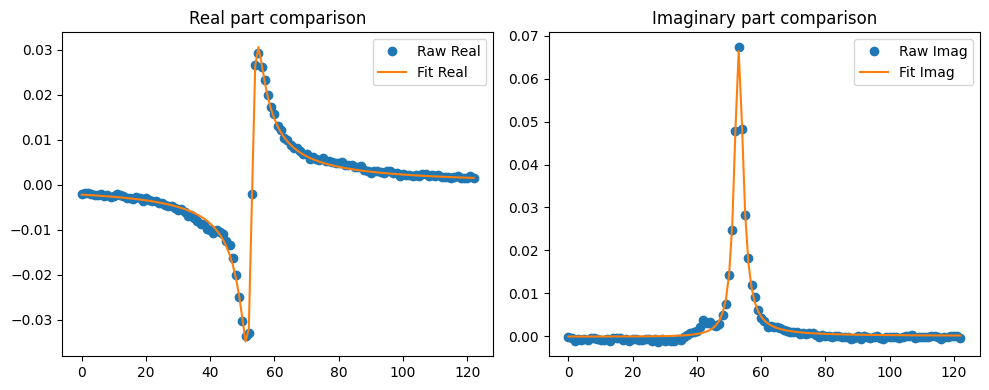

In [33]:
x, y, dc_idx, field, cycle = 1,1,30,0,0
raw_resp = beps_raw[x, y, :, dc_idx, field, cycle].compute()
raw_real = np.real(raw_resp)
raw_imag = np.imag(raw_resp)
pix_index=(((x*ny+y)*ndc+dc_idx)*nfield+field)*ncycle+cycle 
print(pix_index)
fit_real = fit_curves[pix_index, :123]
fit_imag = fit_curves[pix_index, 123:]

# Plot comparison
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(raw_real, 'o', label='Raw Real')
plt.plot(fit_real, '-', label='Fit Real')
plt.legend(); plt.title("Real part comparison")

plt.subplot(1, 2, 2)
plt.plot(raw_imag, 'o', label='Raw Imag')
plt.plot(fit_imag, '-', label='Fit Imag')
plt.legend(); plt.title("Imaginary part comparison")
plt.tight_layout()
plt.show()

(array([  1.,   5.,   7.,   2.,   3.,   4.,   9.,  18.,  71., 136.]),
 array([0.74090135, 0.76648575, 0.79207014, 0.81765454, 0.84323893,
        0.86882332, 0.89440772, 0.91999211, 0.9455765 , 0.9711609 ,
        0.99674529]),
 <BarContainer object of 10 artists>)

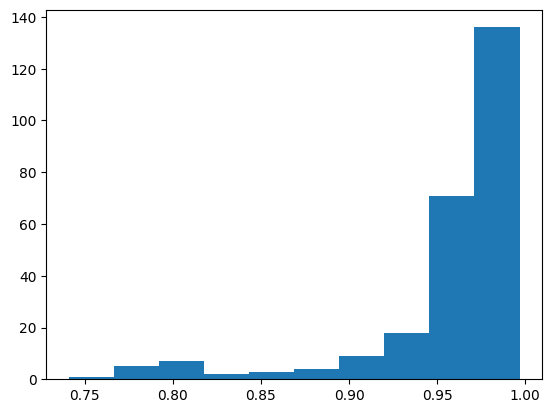

In [34]:
plt.hist(r2_map.flatten())

In [35]:
r2_mean = r2_map.mean(axis=2)   # average across DC bias
r2_std = r2_map.std(axis=2)   # average across DC bias
print("Mean R² shape:", r2_mean.shape)
print("std R² shape:", r2_std.shape)
print(r2_map.shape)

Mean R² shape: (2, 2, 1, 1)
std R² shape: (2, 2, 1, 1)
(2, 2, 64, 1, 1)


In [36]:
# r2_mean

In [37]:
# r2_std

(array([1., 0., 0., 0., 1., 0., 1., 0., 0., 1.]),
 array([0.92875703, 0.93443712, 0.9401172 , 0.94579729, 0.95147738,
        0.95715747, 0.96283756, 0.96851765, 0.97419774, 0.97987783,
        0.98555792]),
 <BarContainer object of 10 artists>)

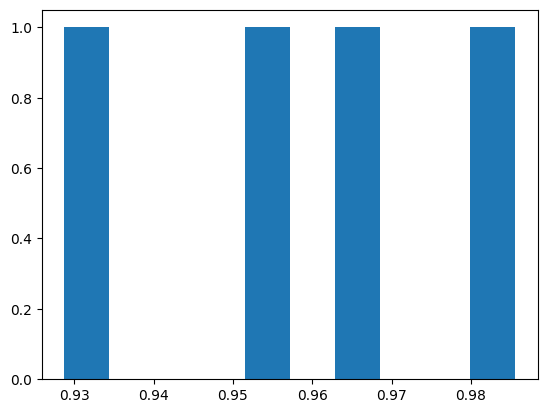

In [38]:
plt.hist(r2_mean.flatten())

In [39]:
###############################################################
## loop fitting
###############################################################

In [40]:
fit_params.shape, fit_curves.shape

((2, 2, 64, 1, 1, 4), (256, 246))

(64,) (64,) (64,)
Projected loop shape: (64,)
Rotation angle, offset: (3.309611908430927, 4.4782634287959835e-05)
Centroid: (0.49058292527293446, -2.878165884229269e-05)
Geometric Area: 0.0033966011719731054


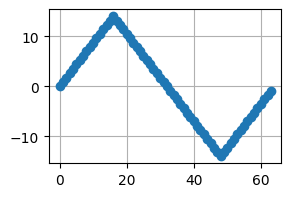

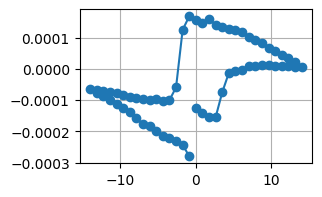

In [41]:
## non-shifted 
vdc_vec = beps_raw._axes[3].values
amp_vec = fit_params[0, 0, :, 0, 0, 0]   # amplitude across 64 DC steps
phase_vec = fit_params[0, 0, :, 0, 0, 3] # phase across 64 DC steps
print(vdc_vec.shape, amp_vec.shape, phase_vec.shape)
loop_result = projectLoop(vdc_vec, amp_vec, phase_vec)
print("Projected loop shape:", loop_result['Projected Loop'].shape)
print("Rotation angle, offset:", loop_result['Rotation Matrix'])
print("Centroid:", loop_result['Centroid'])
print("Geometric Area:", loop_result['Geometric Area'])
##
plt.figure(figsize=(3,2))
plt.plot(vdc_vec, marker="o")
plt.grid(True)
plt.show()
##
plt.figure(figsize=(3,2))
plt.plot(vdc_vec, loop_result['Projected Loop'], 'o-')
plt.grid(True)
plt.show()

(64,) (64,) (64,)
Projected loop shape: (64,)
Rotation angle, offset: (3.309611909239128, 4.478277791615772e-05)
Centroid: (0.35046959503549346, -3.065028116641949e-05)
Geometric Area: 0.003498356082162055


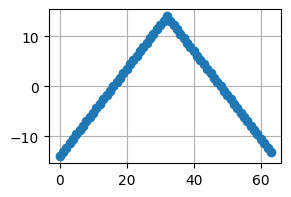

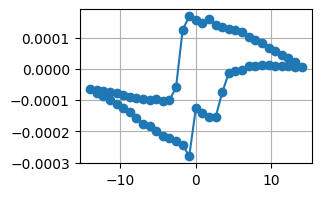

In [42]:
## shifted 
vdc_vec = beps_raw._axes[3].values
amp_vec = fit_params[0, 0, :, 0, 0, 0]   # amplitude across 64 DC steps
phase_vec = fit_params[0, 0, :, 0, 0, 3] # phase across 64 DC steps
##
vdc_vec = np.roll(vdc_vec, int(1* len(vdc_vec)/4))
amp_vec = np.roll(amp_vec, int(1* len(amp_vec)/4))
phase_vec = np.roll(phase_vec, int(1* len(phase_vec)/4))
##
print(vdc_vec.shape, amp_vec.shape, phase_vec.shape)
loop_result = projectLoop(vdc_vec, amp_vec, phase_vec)
print("Projected loop shape:", loop_result['Projected Loop'].shape)
print("Rotation angle, offset:", loop_result['Rotation Matrix'])
print("Centroid:", loop_result['Centroid'])
print("Geometric Area:", loop_result['Geometric Area'])
##
plt.figure(figsize=(3,2))
plt.plot(vdc_vec, marker="o")
plt.grid(True)
plt.show()
##
plt.figure(figsize=(3,2))
plt.plot(vdc_vec, loop_result['Projected Loop'], 'o-')
plt.grid(True)
plt.show()

In [43]:
loops = np.zeros((nx, ny, nfield, ncycle, ndc))   # storage for projected loops
for i in range(nx):       # row
    for j in range(ny):   # col
        for f in range(nfield):  # field
            for c in range(ncycle):  # cycle
                vdc_vec = beps_raw._axes[3].values                
                amp_vec = fit_params[i, j, :, f, c, 0]
                phase_vec = fit_params[i, j, :, f, c, 3]
                ##
                vdc_vec = np.roll(vdc_vec, int(1* len(vdc_vec)/4))
                amp_vec = np.roll(amp_vec, int(1* len(amp_vec)/4))
                phase_vec = np.roll(phase_vec, int(1* len(phase_vec)/4))
                ##
                loop_result = projectLoop(vdc_vec, amp_vec, phase_vec)
                loops[i, j, f, c, :] = loop_result['Projected Loop']
print(loops.shape)

(2, 2, 1, 1, 64)


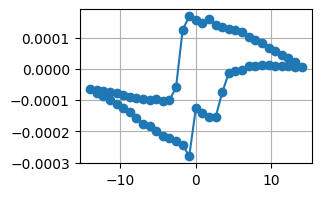

In [44]:
i,j,f,c=0,0,0,0
vdc_vec = beps_raw._axes[3].values
vdc_vec = np.roll(vdc_vec, int(1* len(vdc_vec)/4))
plt.figure(figsize=(3,2))
plt.plot(vdc_vec, loops[i,j,f,c,:], 'o-')
plt.grid(True)
plt.show()

In [45]:
##############################################
## trial
##############################################


===================================================================================== 0

(64,) (64,)
[-2.65993192e-04  2.55875520e-04 -1.28476626e+01 -2.82614961e-01
  0.00000000e+00  2.69329193e+00  1.70403521e+00  2.54471843e+00
  1.36979291e+00]


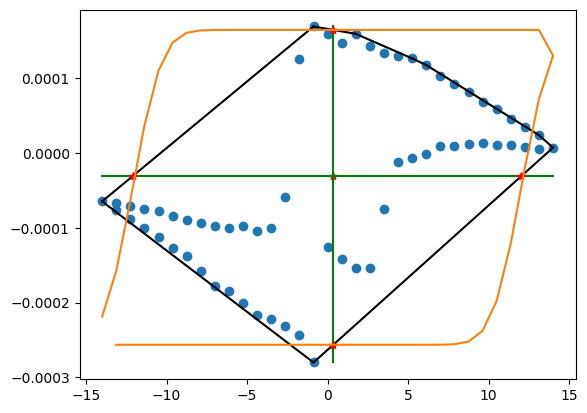

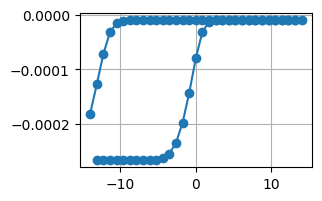

Optimal parameters shape: (9,)
Covariance matrix shape: (9, 9)


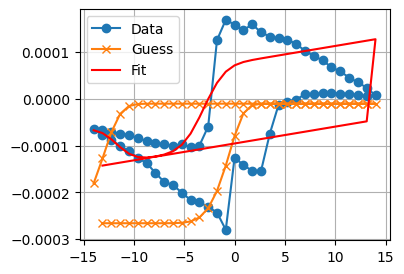


===================================================================================== 1

(64,) (64,)
Error:  list index out of range
[-2.13343906e-04  3.13895586e-04 -1.61598772e+00  5.30339051e+00
  0.00000000e+00  2.39580030e+00  2.57598196e+00  1.86527380e+00
  1.90423775e+00]


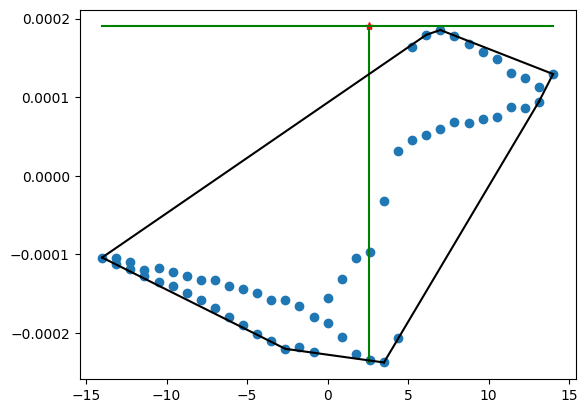

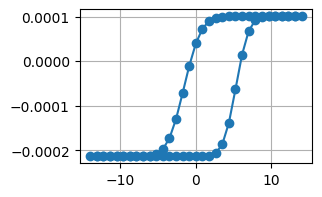

Optimal parameters shape: (9,)
Covariance matrix shape: (9, 9)


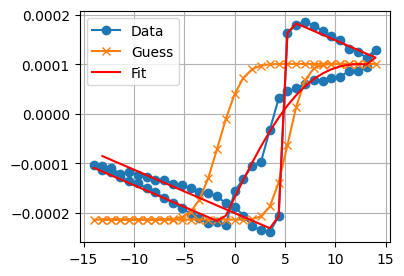


===================================================================================== 2

(64,) (64,)
[-1.45356015e-04  1.34568401e-04 -6.08678227e+00  1.11813201e+01
  0.00000000e+00  2.76127166e+00  1.87659858e+00  1.36865949e+00
  1.60192287e+00]


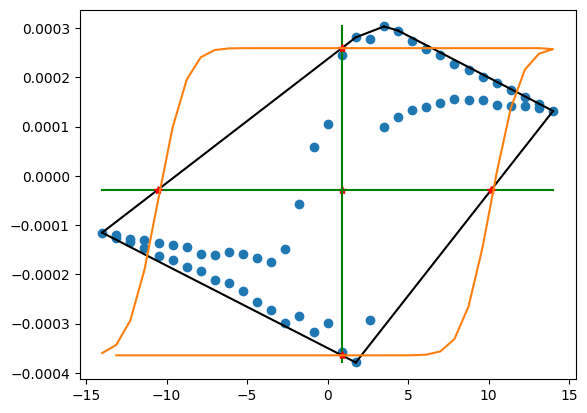

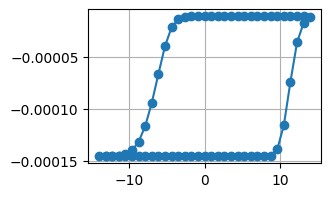

Optimal parameters shape: (9,)
Covariance matrix shape: (9, 9)


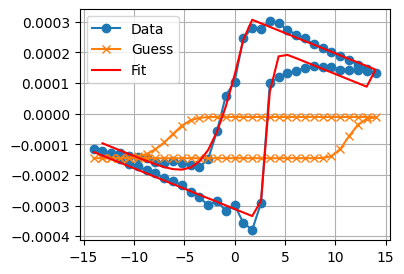


===================================================================================== 3

(64,) (64,)
[-2.12274714e-04  2.81264517e-04 -2.98783513e+00  3.47896574e+00
  0.00000000e+00  1.67487501e+00  3.18216181e+00  1.54123914e+00
  3.33659603e+00]


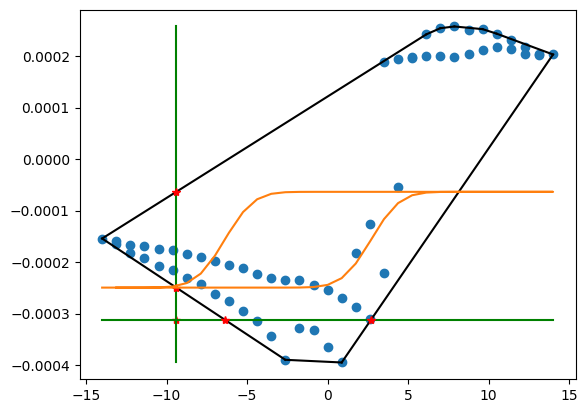

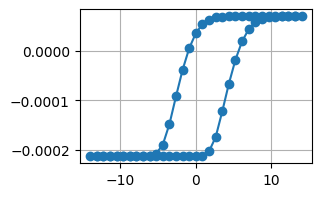

Optimal parameters shape: (9,)
Covariance matrix shape: (9, 9)


C:\Users\m2u\AppData\Local\Temp\ipykernel_10632\864225644.py:36: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(loop_fit_function, x_vdc, y_loop, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=5000)


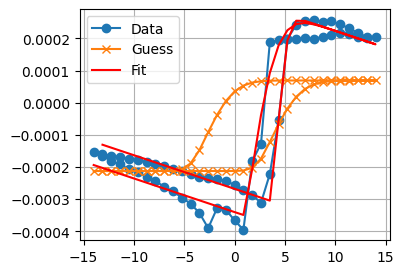

In [46]:
plot_no=0
for i in range(2):
    for j in range(2):
        for f in range(1):
            for c in range(1):
                print()
                print('=====================================================================================', plot_no)
                print()
                plot_no+=1
                ##
                ##
                # i,j,f,c=0,0,0,1
                ##
                ##
                vdc_vec = beps_raw._axes[3].values
                vdc_vec = np.roll(vdc_vec, int(1* len(vdc_vec)/4))                
                y_loop = loops[i, j, f, c, :]
                x_vdc = vdc_vec
                print(y_loop.shape, x_vdc.shape)
                p0 = generate_shallow_guess(x_vdc, y_loop, show_plots=True)
                print(p0)
                ##
                ##
                y_vdc = loop_fit_function(x_vdc, *p0)
                plt.figure(figsize=(3,2))
                plt.plot(x_vdc, y_vdc, 'o-', label='Guess')
                plt.grid(True)
                plt.show()
                ##
                # Fit using your loop_fit_function
                lower_bounds = [-np.inf]*9
                upper_bounds = [np.inf]*9
                ##
                ##
                try:
                    popt, pcov = curve_fit(loop_fit_function, x_vdc, y_loop, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=5000)                
                    print("Optimal parameters shape:", popt.shape)
                    print("Covariance matrix shape:", pcov.shape)                    
                except Exception as e:
                    print(e)
                    popt = p0
                    print("Optimal parameters shape:", popt.shape)                    
                # Compare fit vs data
                plt.figure(figsize=(4,3))
                plt.plot(x_vdc, y_loop, 'o-', label='Data')
                plt.plot(x_vdc, y_vdc, 'x-', label='Guess')                                
                plt.plot(x_vdc, loop_fit_function(x_vdc, *popt), 'r-', label='Fit')
                plt.grid(True)
                plt.legend()
                plt.show()
                ##

In [47]:
##############################################
## with total dataset
##############################################

In [48]:
# loops shape: (5, 5, 2, 2, 64)
loop_dset = sidpy.sid.Dataset.from_array(loops, title='Projected Loops')
loop_dset.data_type = 'image_stack'
# Add dimensions: row, col, field, cycle, Vdc
loop_dset.set_dimension(0, Dimension(np.arange(loops.shape[0]), name='row', units='px'))
loop_dset.set_dimension(1, Dimension(np.arange(loops.shape[1]), name='col', units='px'))
loop_dset.set_dimension(2, Dimension(np.arange(loops.shape[2]), name='field', units='idx'))
loop_dset.set_dimension(3, Dimension(np.arange(loops.shape[3]), name='cycle', units='idx'))
loop_dset.set_dimension(4, Dimension(vdc_vec, name='Vdc', units='V', quantity='bias', dimension_type='spectral'))

In [49]:
ind_dims = (0, 1, 2, 3)  # row, col, field, cycle

In [50]:
num_clusters = 6
num_workers = 6
kmeans_guess = False
fitter_loop = SidFitter(
    loop_dset,
    loop_fit_function,
    xvec=vdc_vec,
    num_workers=num_workers,
    guess_fn=generate_shallow_guess,
    ind_dims=ind_dims,
    threads=1,
    return_cov=False,
    return_fit=True,
    return_std=False,
    km_guess=kmeans_guess,
    num_fit_parms=9,   # Amp, Freq, Q, Phase
    # n_clus=num_clusters
)

Setting Ind_dims from given values from user


In [51]:
fitter_loop.do_guess()
print("Guess shape:", fitter_loop.prior.shape)

Guess shape: (4, 9)


In [52]:
fitter_loop.prior[0]

array([-6.95187354e-05,  8.50856803e-05, -9.80259541e+00,  6.83990080e+00,
        0.00000000e+00,  1.88282678e+00,  2.08491774e+00,  2.32344088e+00,
        1.89650646e+00])

In [53]:
fitter_loop_output = fitter_loop.do_fit()

In [54]:
len(fitter_loop_output)

2

In [55]:
# --- Step 3: Unpack results ---
fit_loop_params = np.array(fitter_loop_output[0].compute())   # fitted coefficients
print("fit_loop_params shape:", fit_loop_params.shape)

fit_loop_params shape: (2, 2, 1, 1, 9)


In [56]:
fit_loop_curves = np.array(fitter_loop_output[1].compute())
print("fit_loop_curves shape:", fit_loop_curves.shape)

fit_loop_curves shape: (2, 2, 1, 1, 64)


In [57]:
fit_loop_params[0,0,0,0,:]

array([-1.89283389e-04,  3.50967967e-04, -4.78608466e-01, -1.43543953e+00,
       -1.15942713e-05, -6.35478680e-01,  8.25593896e+00,  1.75714413e+00,
       -3.57731110e-02])

In [58]:
fit_loop_curves[0,0,0,0,:]

array([-8.54988109e-05, -9.56437983e-05, -1.05788786e-04, -1.15933773e-04,
       -1.26078761e-04, -1.36223748e-04, -1.46368735e-04, -1.56513723e-04,
       -1.66658710e-04, -1.76803698e-04, -1.86948685e-04, -1.97093673e-04,
       -2.07238660e-04, -2.17383595e-04, -2.27392141e-04, -2.26619242e-04,
       -1.93706204e-04, -1.58976075e-04, -1.25775905e-04, -9.49818906e-05,
       -6.73178433e-05, -4.33187366e-05, -2.33130334e-05, -7.42403944e-06,
        4.41187814e-06,  1.24141980e-05,  1.69193060e-05,  1.83389114e-05,
        1.71204372e-05,  1.37128907e-05,  8.54034474e-06,  1.98379973e-06,
        1.39522394e-05,  2.40972268e-05,  3.42422142e-05,  4.43872017e-05,
        5.45321891e-05,  6.46771765e-05,  7.48221639e-05,  8.49671514e-05,
        9.51121388e-05,  1.05257126e-04,  1.15402114e-04,  1.25547101e-04,
        1.35692088e-04,  1.45837076e-04,  1.55982063e-04,  1.66127051e-04,
        1.76272038e-04,  1.86417026e-04,  1.17665048e-04, -3.76253493e-05,
       -1.14100269e-04, -

In [59]:
# fit_loop_params


===================================================================================== 0

(64,) (64,)


C:\Users\m2u\AppData\Local\Temp\ipykernel_10632\1773973912.py:22: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(loop_fit_function, x_vdc, y_loop, p0=p0, maxfev=5000)


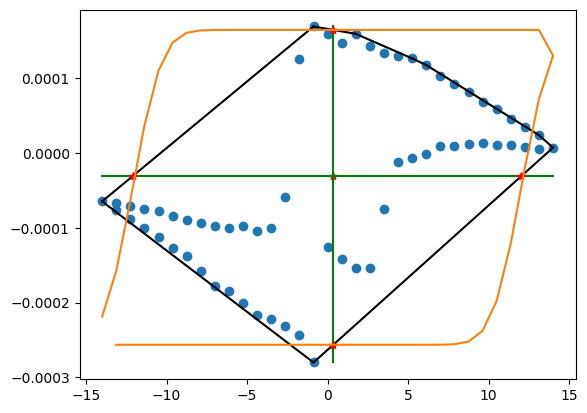

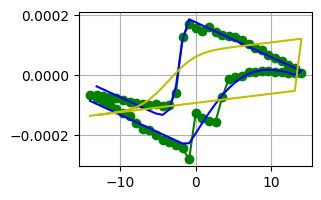


===================================================================================== 1

(64,) (64,)
Error:  list index out of range


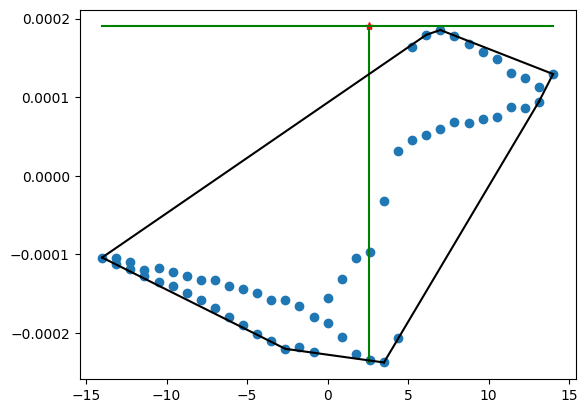

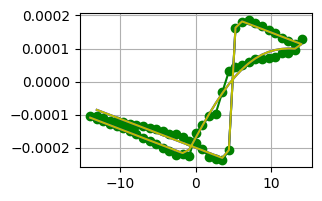


===================================================================================== 2

(64,) (64,)


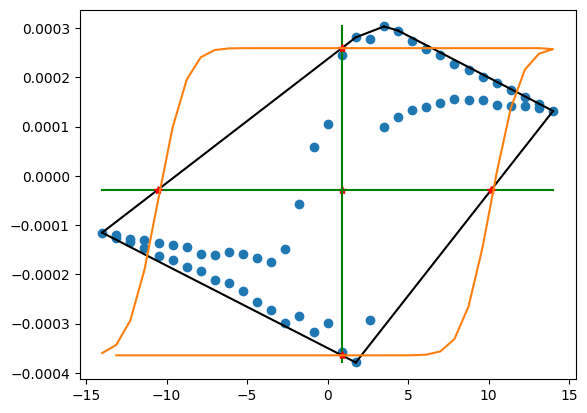

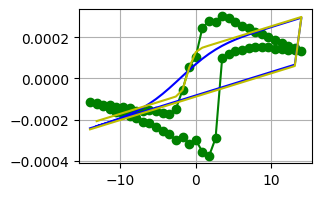


===================================================================================== 3

(64,) (64,)


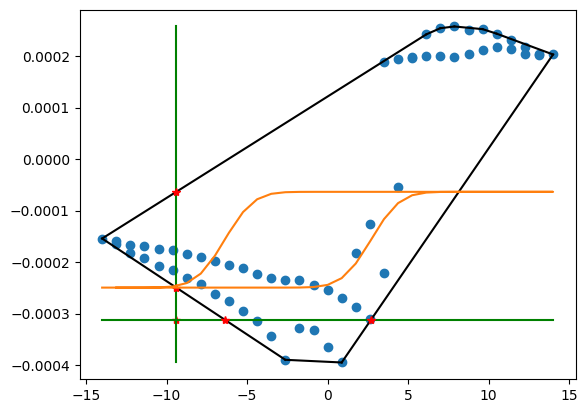

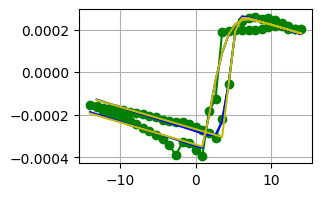

In [60]:
plot_no=0
index_no=0
for i in range(2):
    for j in range(2):
        for f in range(1):
            for c in range(1):
                print()
                print('=====================================================================================', plot_no)
                print()
                plot_no+=1
                ##
                ##
                # i,j,f,c=0,0,0,1
                ##
                ##
                vdc_vec = beps_raw._axes[3].values
                vdc_vec = np.roll(vdc_vec, int(1* len(vdc_vec)/4))                
                y_loop = loops[i, j, f, c, :]
                x_vdc = vdc_vec
                print(y_loop.shape, x_vdc.shape)
                p0 = generate_shallow_guess(x_vdc, y_loop, show_plots=True)                
                popt, pcov = curve_fit(loop_fit_function, x_vdc, y_loop, p0=p0, maxfev=5000)                
                plt.figure(figsize=(3,2))
                plt.plot(x_vdc, y_loop, 'go-')
                plt.plot(x_vdc, fit_loop_curves[i, j, f, c, :], 'b-')
                plt.plot(x_vdc, loop_fit_function(x_vdc, *popt), 'y-')                 
                plt.grid(True)
                plt.show()
                index_no +=1

In [102]:
print('done')

done


In [103]:
## get physical measurements

In [104]:
a = fit_loop_params.reshape(-1, 9)

In [105]:
for i in range(a.shape[0]):
    print(a[i])

[-1.89283389e-04  3.50967967e-04 -4.78608466e-01 -1.43543953e+00
 -1.15942713e-05 -6.35478680e-01  8.25593896e+00  1.75714413e+00
 -3.57731110e-02]
[-2.00060850e-04  4.35827359e-04 -9.25209722e-01  4.33073397e+00
 -8.74146434e-06 -3.46967082e-01  1.00290031e+01  7.64041121e-05
  6.93961505e-01]
[-8.26485310e-05  1.40703608e-09 -1.69734624e+01 -1.96844303e+00
  1.14288874e-05  1.05049747e+01  2.05895947e-01  5.42784211e+00
 -5.42777230e+00]
[-2.76898959e-04  6.13034449e-04  1.17834278e+00  4.70669468e+00
 -1.12981065e-05 -1.74140513e-01  3.29002227e+00  1.39123211e+00
  8.50973535e-01]


In [106]:
print(fit_loop_params.shape, a.shape)
b = calc_switching_coef_vec(a)
print(b.shape)
# Suppose b is (N, 1) structured array
b_struct = b[:, 0]  # shape (N,)

# Convert structured dtype → regular float array
c = np.vstack([list(x) for x in b_struct])
print(c.shape)  # (N, 9)


(2, 2, 1, 1, 9) (4, 9)
(4, 1)
(4, 9)


In [107]:
# coef_reshaped = np.array(self.switching_coef, dtype=object).reshape(nx, ny, self.nfield, self.ncycle)
# data = np.vectorize(lambda x: x[param_idx])(coef_reshaped[:, :, field_idx, cycle_idx])